In [1]:
!date

Thu Sep 17 15:32:48 PDT 2026


In [2]:
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
projdir = '/u/project/cluo/terencew/claude/project_ideas/asm_lr_hprc2'
figdir = f'{projdir}/figures/qc'
outdir = f'{projdir}/results/qc/data'
!mkdir -p {figdir}

### measured per-haplotype depth vs HPRC2's reported coverage, all 402 haplotypes (pilot version used 12 donors, one window)

In [4]:
meas = pd.concat([pd.read_csv(f, sep='\t') for f in glob.glob(f'{projdir}/results/meth_bins/per_hap/*.summary.tsv')])
seq = pd.read_csv(f'{projdir}/results/qc/data/supp_seq_qc.csv')[
    ['sample_id', 'coverage_ont', 'coverage_100kb_ont', 'sequencing_chemistry_ont', 'read_N50_ont']].rename(
    columns={'sample_id': 'sample'})
man = pd.read_csv(f'{projdir}/tsv/meta/hprc2_sample_manifest.tsv', sep='\t')[
    ['sample_id', 'superpopulation']].rename(columns={'sample_id': 'sample'})
d = meas.merge(seq, on='sample', how='left').merge(man, on='sample', how='left')
d['ratio_measured_over_reported'] = d['mean_depth'] / d['coverage_ont']

In [5]:
d.head()

,sample,hap,n_cpg_native,global_meth,global_wmeth,mean_depth,median_depth,pmd_native_bp,frac_cpg_in_pmd_native,meth_in_pmd_native,...,n_cpg_hg38,map_rate,pmd_hg38_bp,n_pmd_hg38,coverage_ont,coverage_100kb_ont,sequencing_chemistry_ont,read_N50_ont,superpopulation,ratio_measured_over_reported
0,HG00097,1,32408753,0.517675,0.639523,25.394918,25.0,1552234578,0.403549,0.563313,...,26498393,0.817631,1349212452,794,57.09,25.34,R1041,89210.35,EUR,0.444823
1,HG00097,2,32023247,0.523907,0.634447,25.418936,25.0,1549609087,0.403253,0.561277,...,26461936,0.826335,1340601981,730,57.09,25.34,R1041,89210.35,EUR,0.445243
2,HG00099,1,32420616,0.517486,0.684083,27.427522,27.0,1317374744,0.334136,0.617930,...,26448515,0.815793,1170730688,597,58.78,20.75,R941,72139.93,EUR,0.466613
3,HG00099,2,32286272,0.519639,0.678444,27.470538,27.0,1328438984,0.337463,0.617382,...,26468116,0.819795,1133392036,558,58.78,20.75,R941,72139.93,EUR,0.467345
4,HG00126,1,31775871,0.527986,0.668717,33.891916,33.0,1336041742,0.365254,0.621466,...,26469735,0.833014,1191635486,590,70.94,38.34,R1041,107245.82,EUR,0.477755


In [6]:
d.shape

(402, 21)

In [7]:
per_donor = d.groupby(['sample', 'superpopulation', 'sequencing_chemistry_ont']).agg(
    measured_sum=('mean_depth', 'sum'), measured_mean=('mean_depth', 'mean'),
    reported=('coverage_ont', 'first')).reset_index()
per_donor['diploid_ratio'] = per_donor['measured_sum'] / per_donor['reported']
per_donor[['measured_sum', 'reported', 'diploid_ratio']].describe().round(3)

,measured_sum,reported,diploid_ratio
count,197.000,197.000,197.000
mean,60.418,71.269,0.869
std,8.901,16.255,0.118
min,31.299,33.860,0.413
25%,55.087,60.120,0.852
50%,59.551,69.540,0.922
75%,66.982,79.520,0.942
max,83.262,140.460,0.982


In [8]:
# HPRC2's reported coverage is diploid/total; hap1+hap2 measured depth is the comparable quantity
print('donors with diploid ratio < 0.8:', (per_donor.diploid_ratio < 0.8).sum())
print(per_donor.nsmallest(8, 'diploid_ratio')[['sample', 'superpopulation', 'measured_sum', 'reported', 'diploid_ratio']].round(2).to_string(index=False))

donors with diploid ratio < 0.8: 38
 sample superpopulation  measured_sum  reported  diploid_ratio
HG01361             AMR         57.95    140.46           0.41
HG00438             EAS         63.19    136.65           0.46
HG03516             AFR         60.98    126.17           0.48
HG01978             AMR         54.97    109.02           0.50
HG01071             AMR         70.14    133.49           0.53
HG02717             AFR         57.31    107.60           0.53
HG01928             AMR         58.39    104.21           0.56
HG00235             EUR         54.49     91.04           0.60


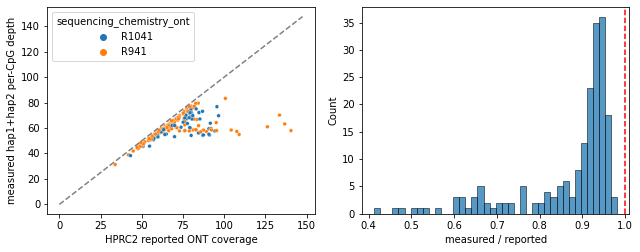

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))
sns.scatterplot(data=per_donor, x='reported', y='measured_sum', hue='sequencing_chemistry_ont', s=14, ax=axes[0])
lim = [0, per_donor[['reported', 'measured_sum']].max().max() * 1.05]
axes[0].plot(lim, lim, ls='--', c='grey')
axes[0].set_xlabel('HPRC2 reported ONT coverage'); axes[0].set_ylabel('measured hap1+hap2 per-CpG depth')
sns.histplot(per_donor.diploid_ratio, bins=40, ax=axes[1]); axes[1].axvline(1, c='r', ls='--')
axes[1].set_xlabel('measured / reported')
plt.tight_layout(); plt.savefig(f'{figdir}/01c_measured_vs_reported_coverage.png', dpi=150)

In [10]:
d.to_csv(f'{outdir}/coverage_measured_vs_reported_all_haps.tsv', sep='\t', index=False)
per_donor.to_csv(f'{outdir}/coverage_measured_vs_reported_per_donor.tsv', sep='\t', index=False)

In [11]:
!date

Thu Sep 17 15:32:54 PDT 2026
